In [1]:
# Gauss-Seidel Implementation on a Four-Bus Microgrid
# NUMMETS-EQ2/E32 Project, Group 7

"""
Setup cell for 4x4 example: given data and imported libraries
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings("ignore")

# bus types:
# bus 1: slack bus (reference, voltage = 1.0, no angle)
# bus 2: generator (PV) bus
# bus 3: load (PQ) bus
# bus 4: load (PQ) bus

# line impedances (resistance + j*reactance) in per-unit
# format: {(from_bus, to_bus): z}
line_impedances = {
    (1, 2): complex(0.02, 0.06),
    (1, 3): complex(0.08, 0.24),
    (2, 3): complex(0.06, 0.18),
    (2, 4): complex(0.06, 0.18),
    (3, 4): complex(0.04, 0.13),
}

# scheduled power injections at each bus (in per-unit)
# positive = generation, negative = load consumption
# format: {bus: (P_scheduled, Q_scheduled)}
bus_power = {
    1: (None,  None),    # slack bus: p and q determined by solution
    2: (0.40,  0.30),    # pv bus: small generator with reactive support
    3: (-0.55, -0.18),   # pq bus: residential load
    4: (-0.45, -0.15),   # pq bus: residential load
}

# voltage specifications per bus
bus_voltage_spec = {
    1: complex(1.05, 0.0),  # slack: 1.05 pu, no angle
    2: 1.02,                # pv: |V| = 1.02 pu (angle unknown)
    3: complex(1.0, 0.0),   # initial flat-start guess
    4: complex(1.0, 0.0),   # initial flat-start guess
}

# convergence settings
MAX_ITERATIONS = 100
TOLERANCE = 1e-6       # convergence threshold in per-unit
ACCEL_FACTOR = 1.3     # gauss-seidel acceleration factor (1.0 = no acceleration)

In [2]:
# Admittance matrix building

def build_ybus(impedances, n_buses=4):
    """
    Constructs and returns the nodal admittance matrix Y from line impedance data.
    y_bus[i][j] = -y_ij for off-diagonal (mutual admittance)
    y_bus[i][i] = sum of all y_ij connected to bus i (self admittance)
    """
    Y = np.zeros((n_buses, n_buses), dtype=complex)

    for (i, j), z in impedances.items():
        y = 1.0 / z # line admittance = inverse of impedance
        ii, jj = i - 1, j - 1

        # off-diagonal elements (negative mutual admittance)
        Y[ii][jj] -= y
        Y[jj][ii] -= y

        # diagonal elements (self admittance accumulates)
        Y[ii][ii] += y
        Y[jj][jj] += y

    return Y


In [3]:
# Gauss-Seidel main function

def gauss_seidel_power_flow(Y, bus_power, bus_voltage_spec,
                             bus_types=None,
                             max_iter=MAX_ITERATIONS,
                             tol=TOLERANCE,
                             accel=ACCEL_FACTOR):
    """
    Solves bus voltages using the Gauss-Seidel iterative method and
    prints a table showing the voltages per bus and the convergence error
    at every iteration.

    bus_types: optional dict {bus_number: 'slack'|'pv'|'pq'}.
               Defaults to the original 4-bus example layout when omitted
               (bus 1 = slack, bus 2 = pv, buses 3-4 = pq).

    Returns the voltage array (V), a list of voltage arrays (history),
    and a list of relative errors (rel_errs).
    """

    n = Y.shape[0]

    # default bus-type map: reproduce the original 4-bus behaviour
    if bus_types is None:
        bus_types = {1: 'slack', 2: 'pv'}
        for b in range(3, n + 1):
            bus_types[b] = 'pq'

    # build initial voltage vector from bus_voltage_spec
    V = np.array([
        complex(bus_voltage_spec[b]) if bus_types[b] != 'pv'
        else complex(bus_voltage_spec[b], 0.0)
        for b in range(1, n + 1)
    ], dtype=complex)

    history = [V.copy()]
    rel_errs = []

   # display table's arbitrary values
    bus_w = 22
    err_w = 12
    iter_w = 12
    sep = '-' * (iter_w + bus_w * n + err_w)

    print(f"\n\t{sep}")
    print(f"\t{'Iter':^{iter_w}}", end='')
    for b in range(1, n + 1):
        print(f"{'Bus ' + str(b):^{bus_w}}", end='')
    print(f"{'max|dV/V|':^{err_w}}")

    print(f"\t{'':^{iter_w}}", end='')
    for _ in range(n):
        print(f"{'|V|(pu)':^11}{'angle (°)':^11}", end='')
    print(f"{'':^{err_w}}")
    print(f"\t{sep}")

    print(f"\t{'0 (flat)':^{iter_w}}", end='')
    for v in V:
        print(f"{abs(v):^11.6f}{np.degrees(np.angle(v)):^11.4f}", end='')
    print(f"{'--':^{err_w}}")
    print(f"\t{sep}")

    for iteration in range(max_iter):
        V_prev = V.copy()

        for i in range(n):
            bus = i + 1
            btype = bus_types[bus]

            if btype == 'slack':          # slack bus voltage is fixed
                continue

            P_sch, Q_sch = bus_power[bus]
            sum_yv = sum(Y[i][j] * V[j] for j in range(n) if j != i)

            if btype == 'pv':             # PV bus, meant for phasor angle calculations
                Q_calc = -np.imag(np.conj(V[i]) * (Y[i] @ V))
                Q_sch = Q_calc
                V_new = (1.0 / Y[i][i]) * ((P_sch - 1j * Q_sch) / np.conj(V[i]) - sum_yv)
                V_new = bus_voltage_spec[bus] * (V_new / abs(V_new))
            else:                         # PQ bus
                V_new = (1.0 / Y[i][i]) * ((P_sch - 1j * Q_sch) / np.conj(V[i]) - sum_yv)

            V[i] = V_prev[i] + accel * (V_new - V_prev[i])

        rel_err = np.max(np.abs((V - V_prev) / V))
        rel_errs.append(rel_err)
        history.append(V.copy())

        converged = rel_err < tol
        label = f"{iteration + 1}" + (" [done]" if converged else "") # final iteration reached
        print(f"\t{label:^{iter_w}}", end='')
        for v in V:
            print(f"{abs(v):^11.6f}{np.degrees(np.angle(v)):^11.4f}", end='')
        print(f"{rel_err:^{err_w}.2e}")

        if converged:
            print(f"\t{sep}")
            print(f"\t  Converged at iteration {iteration + 1}  (e% = {rel_err:.2e})")
            break
    else:
        print(f"\t{sep}")
        print(f"\t  Did not converge within {max_iter} iterations.")

    print(f"\t{sep}\n")
    return V, history, rel_errs


In [4]:
# Power flow calculation through each line

def compute_line_flows(V, impedances):
    """
    Calculates complex power flowing through each transmission line.
    s_ij = V_i * conj( (V_i - V_j) / z_ij )
    Note: positive s_ij means power flows from bus i to bus j.
    """
    flows = {}
    for (i, j), z in impedances.items():
        ii, jj = i - 1, j - 1
        y_line = 1.0 / z
        I_ij   = (V[ii] - V[jj]) * y_line    # current from i to j
        S_ij   = V[ii] * np.conj(I_ij)       # apparent power from i
        S_ji   = V[jj] * np.conj(-I_ij)      # apparent power from j
        loss   = S_ij + S_ji                 # total line loss
        flows[(i, j)] = {
            "S_ij_MW":   round(S_ij.real * 100, 4),
            "S_ij_MVAr": round(S_ij.imag * 100, 4),
            "S_ji_MW":   round(S_ji.real * 100, 4),
            "S_ji_MVAr": round(S_ji.imag * 100, 4),
            "loss_MW":   round(loss.real * 100, 4),
            "loss_MVAr": round(loss.imag * 100, 4),
        }
    return flows

In [5]:
# Slack-bus injection power calculation

def compute_slack_injection(V, Y):
    """
    Back-calculates the power injected by the slack bus (bus 1)
    using the converged voltages and the y-bus matrix.
    s_slack = V_1 * conj( sum_j Y_1j * V_j )
    """
    I_slack = Y[0] @ V
    S_slack = V[0] * np.conj(I_slack)
    return S_slack

In [6]:
# Results printing

def print_results(V, Y, bus_power, flows, rel_errs, bus_types=None):
    """
    Prints a formatted summary of the power flow solution.
    Note: defaults to the 4x4 example when other information not given.
    """

    n = len(V)

    # default bus-type map: reproduce the original 4-bus behaviour
    if bus_types is None:
        bus_types = {1: 'slack', 2: 'pv'}
        for b in range(3, n + 1):
            bus_types[b] = 'pq'

    type_label = {'slack': 'slack', 'pv': 'PV (Gen.)', 'pq': 'PQ (Load)'}

    print("\tVoltage estimation results")

    print("\n\tBus voltages (converged solution):\n")
    print(f"\t{'bus':<6} {'|V| (pu)':<12} {'angle (°)':<14} {'type':<10}")
    print("\t" + "-" * 44)

    for i, v in enumerate(V):
        bus   = i + 1
        mag   = abs(v)
        ang   = np.degrees(np.angle(v))
        btype = type_label[bus_types[bus]]
        print(f"\t{bus:<6} {mag:<12.6f} {ang:<14.6f} {btype:<10}")

    S_slack = compute_slack_injection(V, Y)
    print(f"\n\tSlack bus injection:")
    print(f"\tP = {S_slack.real * 100:.4f} MW")
    print(f"\tQ = {S_slack.imag * 100:.4f} MVAr")

    print("\n\tLine power flows (base = 100 MVA):\n")
    print(f"\t{'line':<10} {'P_ij(MW)':<12} {'Q_ij(MVAr)':<14} {'loss_MW':<12}")
    print("\t" + "-" * 50)
    for (i, j), f in flows.items():
        print(f"\t{i}\u2192{j:<7}  {f['S_ij_MW']:<12} {f['S_ij_MVAr']:<14} {f['loss_MW']:<12}")

    total_loss = sum(f["loss_MW"] for f in flows.values())
    print(f"\n\tTotal real power losses: {total_loss:.4f} MW")
    print(f"\tIterations to convergence: {len(rel_errs)}")


In [7]:
# Results plotting

def plot_results(V, history, rel_errs, flows, Y, impedances=None, bus_types=None):
    """
    Generates a four-panel figure:
      (a) convergence curve - error vs iteration
      (b) voltage profile - magnitude at each bus
      (c) voltage phasors - polar representation
      (d) one-line diagram - microgrid topology with line flows

    impedances: optional dict {(from, to): Z} used for the one-line diagram.
                Defaults to the module-level line_impedances when omitted.
    bus_types:  optional dict {bus_number: 'slack'|'pv'|'pq'}.
                Defaults to the original 4-bus example layout when omitted.
    """
    import math

    n = len(V)

    # fall back to module-level defaults so the original 4-bus call still works
    if impedances is None:
        impedances = line_impedances
    if bus_types is None:
        bus_types = {1: 'slack', 2: 'pv'}
        for b in range(3, n + 1):
            bus_types[b] = 'pq'

    color_palette = ["#6700db", "#21db12", "#94a1ed", "#dc12a0", "#ff8800", "#00bcd4"]
    colors = color_palette[:n]

    type_short = {'slack': 'Slack', 'pv': 'PV Gen', 'pq': 'PQ Load'}
    bus_labels = [f"Bus {b}\n({type_short[bus_types[b]]})" for b in range(1, n + 1)]

    fig = plt.figure(figsize=(16, 12))
    fig.patch.set_facecolor("#ffffff")
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

    # panel a: convergence curve
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.semilogy(range(1, len(rel_errs) + 1), rel_errs,
                 color="#E91E63", linewidth=2, marker="o", markersize=4)
    ax1.axhline(TOLERANCE, color="gray", linestyle="--", linewidth=1, label=f"tol = {TOLERANCE}")
    ax1.set_xlabel("Iteration number", fontsize=10)
    ax1.set_ylabel("Max voltage error (pu)", fontsize=10)
    ax1.set_title("(a) Gauss-Seidel convergence", fontsize=11, fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.grid(True, which="both", alpha=0.4)
    ax1.set_facecolor("#ffffff")

    # panel b: voltage magnitude profile
    ax2 = fig.add_subplot(gs[0, 1])
    magnitudes = [abs(v) for v in V]
    bars = ax2.bar(range(1, n + 1), magnitudes, color=colors, edgecolor="white",
                   linewidth=1.5, width=0.5)
    ax2.axhline(0.95, color="black", linestyle="--", linewidth=1.2, label="0.95 pu lower limit")
    ax2.axhline(1.05, color="black", linestyle="--", linewidth=1.2, label="1.05 pu upper limit")
    for bar, mag in zip(bars, magnitudes):
        ax2.text(bar.get_x() + bar.get_width() / 2, mag + 0.002,
                 f"{mag:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax2.set_xticks(range(1, n + 1))
    ax2.set_xticklabels(bus_labels, fontsize=9)
    ax2.set_ylabel("|V| (per unit)", fontsize=10)
    ax2.set_title("(b) Bus voltage magnitudes", fontsize=11, fontweight="bold")
    ax2.set_ylim(0.90, 1.10)
    ax2.legend(fontsize=8)
    ax2.grid(axis="y", alpha=0.4)
    ax2.set_facecolor("#ffffff")

    # panel c: phasor diagram (polar)
    ax3 = fig.add_subplot(gs[1, 0], projection="polar")
    for v, col, lbl in zip(V, colors, bus_labels):
        angle = np.angle(v)
        mag   = abs(v)
        ax3.annotate("", xy=(angle, mag), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color=col, lw=2.0))
        ax3.plot(angle, mag, "o", color=col, markersize=8, label=lbl.replace("\n", " "))
    ax3.set_title("(c) Voltage phasors", fontsize=11, fontweight="bold", pad=18)
    ax3.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)
    ax3.set_facecolor("#ffffff")

    # panel d: one-line diagram
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.set_facecolor("#ffffff")
    ax4.set_xlim(0, 10)
    ax4.set_ylim(0, 10)
    ax4.axis("off")
    ax4.set_title("(d) Microgrid one-line diagram", fontsize=11, fontweight="bold")

    # distribute bus positions evenly around a circle
    cx, cy, r = 5, 5, 3.5
    pos = {}
    for b in range(1, n + 1):
        theta = math.radians(90 - (b - 1) * 360 / n)
        pos[b] = (cx + r * math.cos(theta), cy + r * math.sin(theta))

    # draw lines with flow annotations
    for (i, j) in impedances.keys():
        x1, y1 = pos[i]
        x2, y2 = pos[j]
        ax4.plot([x1, x2], [y1, y2], "k-", linewidth=2, zorder=1)
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        f = flows[(i, j)]
        ax4.text(mx, my + 0.35,
                 f"P={f['S_ij_MW']:.2f}MW",
                 ha="center", fontsize=7.5, color="#555555",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none"))

    # draw bus nodes
    for bus, (x, y) in pos.items():
        ax4.scatter(x, y, s=600, color=colors[bus - 1], zorder=3, edgecolors="white", linewidths=2)
        mag = abs(V[bus - 1])
        ang = np.degrees(np.angle(V[bus - 1]))
        ax4.text(x, y + 0.75,
                 f"Bus {bus}\n|V|={mag:.4f} pu\n\u03b4={ang:.2f}\u00b0",
                 ha="center", fontsize=8, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc=colors[bus - 1] + "33", ec="none"))

    plt.suptitle(
        f"Voltage estimation in a {n}-bus microgrid\n"
        "using the Gauss-Seidel iterative method",
        fontsize=12, fontweight="bold", y=0.99, color="#000000"
    )

    plt.show()


	Gauss-Seidel Power Flow on a Four-Bus Microgrid
	NUMMETS-E32/EQ2 | Group 7

	Y-Bus Matrix:
	 ['+6.2500-18.7500j', '-5.0000+15.0000j', '-1.2500+3.7500j', '+0.0000+0.0000j']
	 ['-5.0000+15.0000j', '+8.3333-25.0000j', '-1.6667+5.0000j', '-1.6667+5.0000j']
	 ['-1.2500+3.7500j', '-1.6667+5.0000j', '+5.0788-15.7770j', '-2.1622+7.0270j']
	 ['+0.0000+0.0000j', '-1.6667+5.0000j', '-2.1622+7.0270j', '+3.8288-12.0270j']



	----------------------------------------------------------------------------------------------------------------
	    Iter            Bus 1                 Bus 2                 Bus 3                 Bus 4          max|dV/V|  
	              |V|(pu)   angle (°)   |V|(pu)   angle (°)   |V|(pu)   angle (°)   |V|(pu)   angle (°)             
	----------------------------------------------------------------------------------------------------------------
	  0 (flat)   1.050000    0.0000    1.020000    0.0000    1.000000    0.0000    1.000000    0.0000        --     
	------------

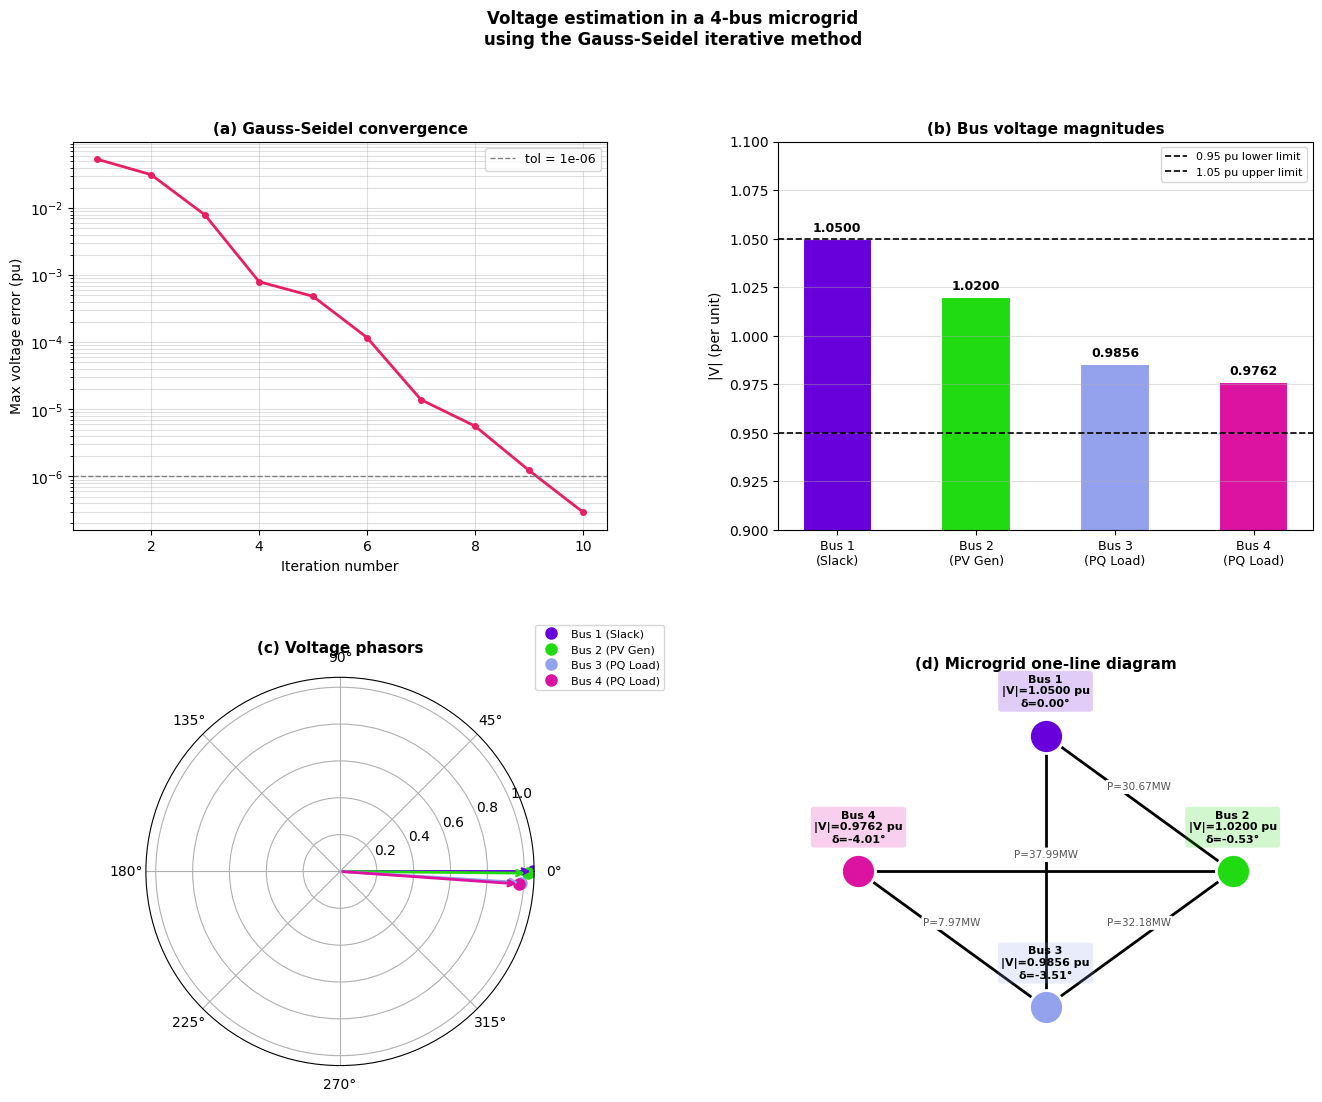

In [8]:
# Main Function
if __name__ == "__main__":
    print("\tGauss-Seidel Power Flow on a Four-Bus Microgrid")
    print("\tNUMMETS-E32/EQ2 | Group 7\n")

    # build admittance matrix
    Y = build_ybus(line_impedances, n_buses=4)
    print("\tY-Bus Matrix:")
    for row in Y:
        print("\t", ["{:+.4f}".format(v) for v in row])
    print("\n")

    # run gauss-seidel iterations
    V_sol, history, rel_errs = gauss_seidel_power_flow(Y, bus_power, bus_voltage_spec)

    # compute line flows
    flows = compute_line_flows(V_sol, line_impedances)

    # print summary
    print_results(V_sol, Y, bus_power, flows, rel_errs)

    # generate plots
    plot_results(V_sol, history, rel_errs, flows, Y)

In [18]:
# User-Input: helper utilities
"""
Shared helper for parsing user-typed complex numbers.
"""
import math
def _parse_complex(s):
    """
    Parses a user-supplied complex number.
    Accepts plain Python complex literals such as  0.02+0.06j  or  -0.55-0.18j.
    """
    s = s.strip()
    try:
        return complex(s)
    except ValueError:
        raise ValueError(f"Cannot parse '{s}' as a complex number.")

def _prompt_voltage(prompt, default):
    """
    Prompt for a complex voltage with a typed default.
    Returns the default unchanged if the user presses Enter.
    """
    raw = input(prompt).strip()
    if not raw:
        return default
    try:
        return _parse_complex(raw)
    except ValueError as e:
        print(f"  [!] {e} — using default {default}")
        return default

print("Gauss-Seidel Power Flow, Interactive Configuration")
while True:
    raw = input("\nHow many buses? (4-6): ").strip()
    try:
        n_buses = int(raw)
        if 4 <= n_buses <= 6:
            break
        print("\t[!] Enter a value between 4 and 6.")
    except ValueError:
        print("\t[!] Please enter a whole number.")

print(f"\nConfiguring a {n_buses}-bus microgrid.")


Gauss-Seidel Power Flow, Interactive Configuration

How many buses? (4-6): 6

Configuring a 6-bus microgrid.


In [21]:
# User-Input: bus-type assignment

"""
Assigns a type to every bus.
Bus 1 is always the slack (reference) bus.
All other buses are either PV (generator, fixed |V|) or PQ (load, fixed P+jQ).
"""

print("\tBus 1 is always the SLACK bus.")
bus_types_map = {1: 'slack'}

for bus in range(2, n_buses + 1):
    while True:
        raw = input(f"\tBus {bus} type: PV (generator) or PQ (load)? [pv/pq]: ").strip().lower()
        if raw in ('pv', 'pq'):
            bus_types_map[bus] = raw
            break
        print("\t[!] Type 'pv' or 'pq'.")

# echo summary
print("\n\tBus-type summary:")
type_label = {'slack': 'slack', 'pv': 'PV (Gen.)', 'pq': 'PQ (Load)'}
for b in range(1, n_buses + 1):
    print(f"\t\tBus {b}: {type_label[bus_types_map[b]]}")


	Bus 1 is always the SLACK bus.
	Bus 2 type: PV (generator) or PQ (load)? [pv/pq]: PV
	Bus 3 type: PV (generator) or PQ (load)? [pv/pq]: PQ
	Bus 4 type: PV (generator) or PQ (load)? [pv/pq]: PQ
	Bus 5 type: PV (generator) or PQ (load)? [pv/pq]: PQ
	Bus 6 type: PV (generator) or PQ (load)? [pv/pq]: PQ

	Bus-type summary:
		Bus 1: slack
		Bus 2: PV (Gen.)
		Bus 3: PQ (Load)
		Bus 4: PQ (Load)
		Bus 5: PQ (Load)
		Bus 6: PQ (Load)


In [11]:
# User-Input: line impedances

"""
Enter the impedance of every transmission line.
Format:  from_bus to_bus R+Xj; e.g.  1 2 0.02+0.06j (no spaces at R+Xj)
Stops at a blank entry (ENTER).
"""

print("\nEnter line impedances (resistance + j*reactance, in per-unit).")
print("Format: from_bus to_bus R+Xj; e.g. 1 2 0.02+0.06j")
print("Press ENTER on a blank line when finished.\n")

user_impedances = {}
while True:
    raw = input("\tConnection (or blank to stop): ").strip()
    if not raw:
        if not user_impedances:
            print("\t[!] At least one connection is required.")
            continue
        break
    parts = raw.split()
    if len(parts) != 3:
        print("\t[!] Expected format:  from_bus  to_bus  R+Xj")
        continue
    try:
        fb, tb = int(parts[0]), int(parts[1])
        z = _parse_complex(parts[2])
    except (ValueError, IndexError) as e:
        print(f"\t[!] {e}")
        continue
    if not (1 <= fb <= n_buses and 1 <= tb <= n_buses and fb != tb):
        print(f"\t[!] Bus numbers must be between 1 and {n_buses} and must differ.")
        continue
    if z == 0:
        print("\t[!] Impedance cannot be zero.")
        continue
    user_impedances[(fb, tb)] = z
    print(f"\tStored: ({fb}, {tb})  Z = {z}")

print(f"\n  {len(user_impedances)} line(s) configured.")



Enter line impedances (resistance + j*reactance, in per-unit).
Format:  from_bus  to_bus  R+Xj; e.g.  1 2 0.02+0.06j
Press ENTER on a blank line when finished.

	Connection (or blank to stop): 1 2 0.02+0.06j
	Stored: (1, 2)  Z = (0.02+0.06j)
	Connection (or blank to stop): 2 3 0.04+0.12j
	Stored: (2, 3)  Z = (0.04+0.12j)
	Connection (or blank to stop): 3 4 0.06+0.18j
	Stored: (3, 4)  Z = (0.06+0.18j)
	Connection (or blank to stop): 4 5 0.05+0.15j
	Stored: (4, 5)  Z = (0.05+0.15j)
	Connection (or blank to stop): 5 6 0.04+0.12j
	Stored: (5, 6)  Z = (0.04+0.12j)
	Connection (or blank to stop): 6 1 0.03+0.1j
	Stored: (6, 1)  Z = (0.03+0.1j)
	Connection (or blank to stop): 1 3 0.08+0.24j
	Stored: (1, 3)  Z = (0.08+0.24j)
	Connection (or blank to stop): 2 5 0.06+0.18j
	Stored: (2, 5)  Z = (0.06+0.18j)
	Connection (or blank to stop): 1 4 0.01+0.05j
	Stored: (1, 4)  Z = (0.01+0.05j)
	Connection (or blank to stop): 

  9 line(s) configured.


In [16]:
# User-Input: scheduled power injections

"""
Enter the scheduled complex-power injection at each non-slack bus.
  PV buses : active power P only (e.g.  0.40)
  PQ buses : P + jQ (e.g. -0.55-0.18j  for a load)
Bus 1 (slack) is skipped, its injection is back-calculated after the solution.
"""

print("\nEnter scheduled complex-power injections (per-unit).")
print("\tPV buses  : enter active power only  e.g.  0.40")
print("\tPQ buses  : enter P + jQ             e.g.  -0.55-0.18j  for a load")
print("Bus 1 (slack) is skipped; its injection is calculated automatically.\n")

user_bus_power = {1: (None, None)}    # slack bus: p and q determined by solution

for bus in range(2, n_buses + 1):
    btype = bus_types_map[bus]
    while True:
        if btype == 'pv':
            raw = input(f"\tBus {bus} (PV): scheduled P [pu]: ").strip()
        else:
            raw = input(f"\tBus {bus} (PQ): scheduled P+Qj [pu]: ").strip()
        if not raw:
            print(f"\t[!] A value is required for bus {bus}.")
            continue
        try:
            s = _parse_complex(raw)
        except ValueError as e:
            print(f"\t[!] {e}")
            continue
        if btype == 'pv':
            # only P matters; Q is computed each iteration
            user_bus_power[bus] = (s.real, 0.0)
            print(f"\tStored: bus {bus} -> P = {s.real:.4f} pu  (Q computed each iteration)")
        else:
            user_bus_power[bus] = (s.real, s.imag)
            print(f"\tStored: bus {bus} -> P = {s.real:.4f} pu,  Q = {s.imag:.4f} pu")
        break



Enter scheduled complex-power injections (per-unit).
	PV buses  : enter active power only  e.g.  0.40
	PQ buses  : enter P + jQ             e.g.  -0.55-0.18j  for a load
Bus 1 (slack) is skipped; its injection is calculated automatically.

	Bus 2 (PV): scheduled P [pu]: 0.55
	Stored: bus 2 -> P = 0.5500 pu  (Q computed each iteration)
	Bus 3 (PQ): scheduled P+Qj [pu]: -0.45-0.15j
	Stored: bus 3 -> P = -0.4500 pu,  Q = -0.1500 pu
	Bus 4 (PQ): scheduled P+Qj [pu]: -0.50-0.20j 
	Stored: bus 4 -> P = -0.5000 pu,  Q = -0.2000 pu
	Bus 5 (PQ): scheduled P+Qj [pu]: -0.35-0.10j
	Stored: bus 5 -> P = -0.3500 pu,  Q = -0.1000 pu
	Bus 6 (PQ): scheduled P+Qj [pu]: -0.40-0.12j
	Stored: bus 6 -> P = -0.4000 pu,  Q = -0.1200 pu


In [13]:
# User-Input: initial voltage specifications

"""
Specify the initial voltage at each bus.
  Bus 1 (slack): fixed complex voltage  (default 1.05+0j)
  PV buses: fixed magnitude only        (default 1.02)
  PQ buses: flat-start complex guess    (default 1.0+0j)
Defaults are set when user enters blank (ENTER).
"""

print("\nEnter voltage specifications (press ENTER to accept the default).")

user_bus_voltage_spec = {}

# bus 1: slack, full complex voltage
v1 = _prompt_voltage("\tBus 1 slack voltage   [default 1.05+0j]: ", complex(1.05, 0.0))
user_bus_voltage_spec[1] = v1

for bus in range(2, n_buses + 1):
    btype = bus_types_map[bus]
    if btype == 'pv':
        # pv bus: magnitude only (float)
        raw = input(f"\tBus {bus} PV magnitude    [default 1.02]: ").strip()
        try:
            mag = float(raw) if raw else 1.02
        except ValueError:
            print("\t[!] Invalid — using default 1.02")
            mag = 1.02
        user_bus_voltage_spec[bus] = mag
    else:
        # pq bus: flat-start complex guess
        v = _prompt_voltage(
            f"\tBus {bus} PQ initial guess [default 1.0+0j]: ",
            complex(1.0, 0.0)
        )
        user_bus_voltage_spec[bus] = v



Enter voltage specifications (press ENTER to accept the default).
	Bus 1 slack voltage   [default 1.05+0j]: 
	Bus 2 PV magnitude    [default 1.02]: 
	Bus 3 PQ initial guess [default 1.0+0j]: 
	Bus 4 PQ initial guess [default 1.0+0j]: 
	Bus 5 PQ initial guess [default 1.0+0j]: 
	Bus 6 PQ initial guess [default 1.0+0j]: 



	Running Gauss-Seidel Power Flow with user-supplied data

	Y-Bus Matrix:
	 ['+12.8484-47.1551j', '-5.0000+15.0000j', '-1.2500+3.7500j', '-3.8462+19.2308j', '+0.0000+0.0000j', '-2.7523+9.1743j']
	 ['-5.0000+15.0000j', '+9.1667-27.5000j', '-2.5000+7.5000j', '+0.0000+0.0000j', '-1.6667+5.0000j', '+0.0000+0.0000j']
	 ['-1.2500+3.7500j', '-2.5000+7.5000j', '+5.4167-16.2500j', '-1.6667+5.0000j', '+0.0000+0.0000j', '+0.0000+0.0000j']
	 ['-3.8462+19.2308j', '+0.0000+0.0000j', '-1.6667+5.0000j', '+7.5128-30.2308j', '-2.0000+6.0000j', '+0.0000+0.0000j']
	 ['+0.0000+0.0000j', '-1.6667+5.0000j', '+0.0000+0.0000j', '-2.0000+6.0000j', '+6.1667-18.5000j', '-2.5000+7.5000j']
	 ['-2.7523+9.1743j', '+0.0000+0.0000j', '+0.0000+0.0000j', '+0.0000+0.0000j', '-2.5000+7.5000j', '+5.2523-16.6743j']



	------------------------------------------------------------------------------------------------------------------------------------------------------------
	    Iter            Bus 1                 Bus 2    

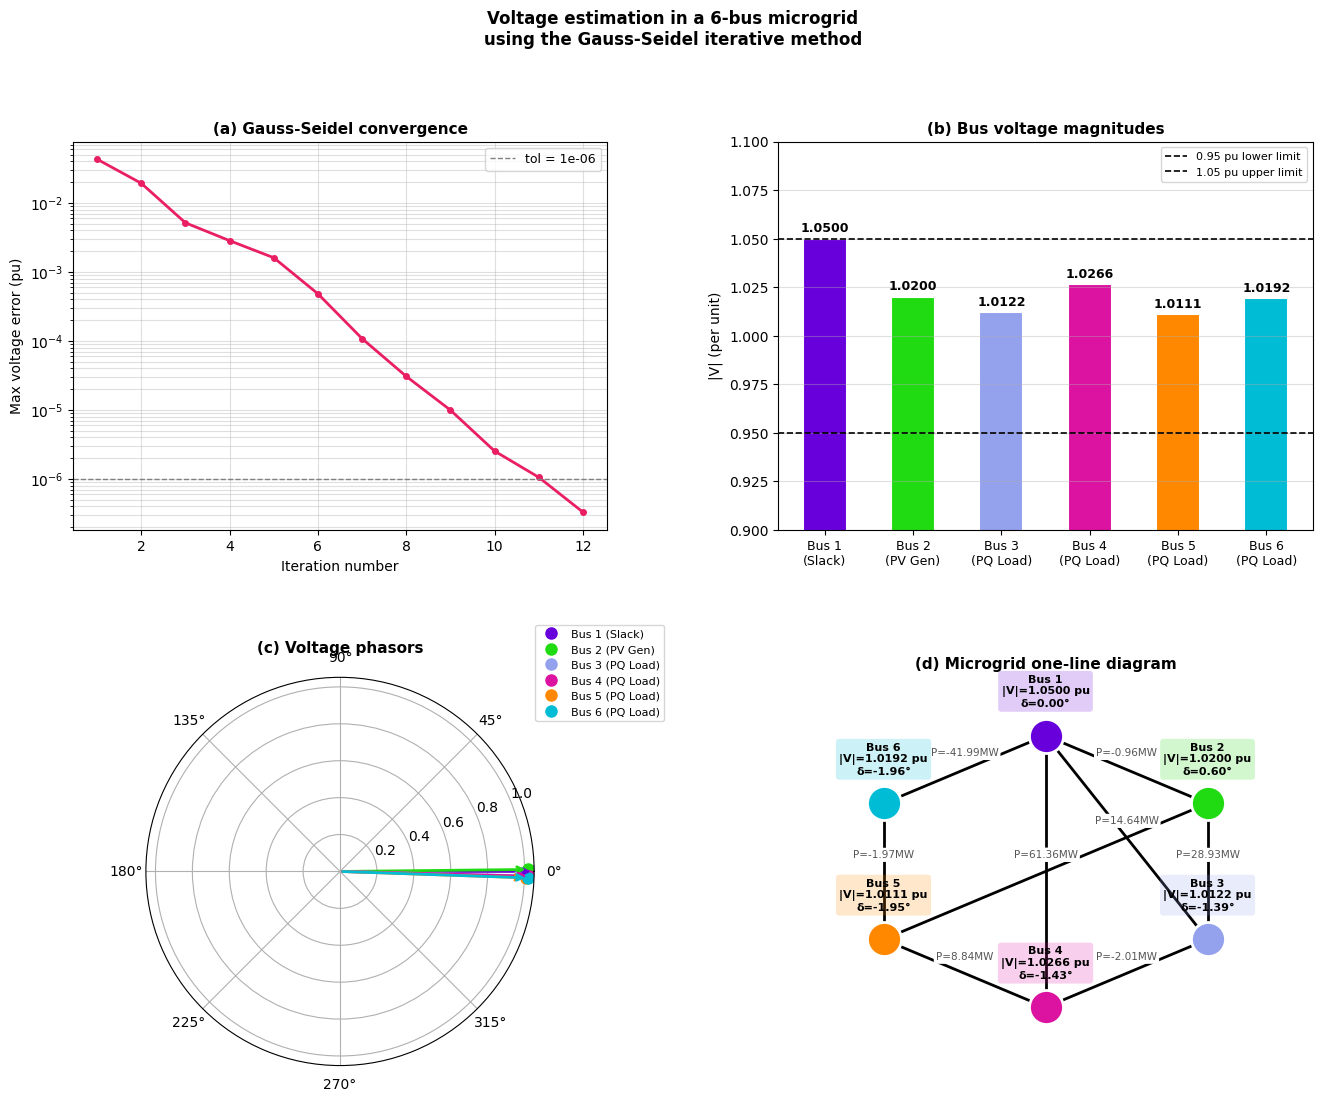

In [20]:
# User-Input: run the analysis

"""
Builds the Y-bus matrix, runs the Gauss-Seidel iterations, computes
line flows, then prints results and plots; all using the same functions
defined in Cells 1–6, now called with the user-supplied data.
"""

print("\n\tRunning Gauss-Seidel Power Flow with user-supplied data")

# build admittance matrix
Y_user = build_ybus(user_impedances, n_buses=n_buses)
print("\n\tY-Bus Matrix:")
for row in Y_user:
    print("\t", ["{:+.4f}".format(v) for v in row])
print("\n")

# run gauss-seidel iterations
V_user, history_user, rel_errs_user = gauss_seidel_power_flow(
    Y_user, user_bus_power, user_bus_voltage_spec, bus_types=bus_types_map
)

# compute line flows
flows_user = compute_line_flows(V_user, user_impedances)

# print summary
print_results(V_user, Y_user, user_bus_power, flows_user, rel_errs_user,
              bus_types=bus_types_map)

# generate plots
plot_results(V_user, history_user, rel_errs_user, flows_user, Y_user,
             impedances=user_impedances, bus_types=bus_types_map)
